In [11]:
import numpy as np
import pandas as pd

In [12]:
train_df = pd.read_csv("C:\\Users\\ado18\\Data\\train.csv")
test_df = pd.read_csv("C:\\Users\\ado18\\Data\\test.csv")

In [13]:
train_df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [14]:
test_df.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag
0,id3004672,1,2016-06-30 23:59:58,1,-73.988129,40.732029,-73.990173,40.756680,N
1,id3505355,1,2016-06-30 23:59:53,1,-73.964203,40.679993,-73.959808,40.655403,N
2,id1217141,1,2016-06-30 23:59:47,1,-73.997437,40.737583,-73.986160,40.729523,N
3,id2150126,2,2016-06-30 23:59:41,1,-73.956070,40.771900,-73.986427,40.730469,N
4,id1598245,1,2016-06-30 23:59:33,1,-73.970215,40.761475,-73.961510,40.755890,N


### Calculate trip distance

In [15]:
# def haversine_distance(lat1, lon1, lat2, lon2):
#     # Convert decimal degrees to radians
#     lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
#     # Haversine formula
#     dlat = lat2 - lat1
#     dlon = lon2 - lon1
#     a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
#     c = 2 * np.arcsin(np.sqrt(a))
    
#     # Earth radius in miles (use 6371 for km)
#     r = 3959
#     return c * r

# train_df['trip_distance'] = haversine_distance(
#     train_df['pickup_latitude'], 
#     train_df['pickup_longitude'], 
#     train_df['dropoff_latitude'], 
#     train_df['dropoff_longitude']
# )

# test_df['trip_distance'] = haversine_distance(
#     test_df['pickup_latitude'], 
#     test_df['pickup_longitude'], 
#     test_df['dropoff_latitude'], 
#     test_df['dropoff_longitude']
# )

# Let's try using Manhattan distance as we are in NYC.
train_df['trip_distance'] = (
    abs(train_df['pickup_longitude'] - train_df['dropoff_longitude']) +
    abs(train_df['pickup_latitude'] - train_df['dropoff_latitude'])
)

test_df['trip_distance'] = (
    abs(test_df['pickup_longitude'] - test_df['dropoff_longitude']) +
    abs(test_df['pickup_latitude'] - test_df['dropoff_latitude'])
)

In [16]:
train_df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,trip_distance
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,0.019859
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0.026478
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,0.080158
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,0.015480
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,0.010818


### Convert to datetime

In [17]:
train_df["pickup_datetime"] = pd.to_datetime(train_df["pickup_datetime"])

train_df["pickup_day_of_week"] = train_df["pickup_datetime"].dt.dayofweek # Monday = 0, Sunday = 6

train_df["pickup_hour"] = train_df["pickup_datetime"].dt.hour

train_df

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,trip_distance,pickup_day_of_week,pickup_hour
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,0.019859,0,17
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0.026478,6,0
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,0.080158,1,11
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,0.015480,2,19
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,0.010818,5,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1458639,id2376096,2,2016-04-08 13:31:04,2016-04-08 13:44:02,4,-73.982201,40.745522,-73.994911,40.740170,N,778,0.018063,4,13
1458640,id1049543,1,2016-01-10 07:35:15,2016-01-10 07:46:10,1,-74.000946,40.747379,-73.970184,40.796547,N,655,0.079929,6,7
1458641,id2304944,2,2016-04-22 06:57:41,2016-04-22 07:10:25,1,-73.959129,40.768799,-74.004433,40.707371,N,764,0.106731,4,6
1458642,id2714485,1,2016-01-05 15:56:26,2016-01-05 16:02:39,1,-73.982079,40.749062,-73.974632,40.757107,N,373,0.015491,1,15


In [18]:
test_df["pickup_datetime"] = pd.to_datetime(test_df["pickup_datetime"])

test_df["pickup_day_of_week"] = test_df["pickup_datetime"].dt.dayofweek # Monday = 0, Sunday = 6

test_df["pickup_hour"] = test_df["pickup_datetime"].dt.hour

test_df

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_distance,pickup_day_of_week,pickup_hour
0,id3004672,1,2016-06-30 23:59:58,1,-73.988129,40.732029,-73.990173,40.756680,N,0.026695,3,23
1,id3505355,1,2016-06-30 23:59:53,1,-73.964203,40.679993,-73.959808,40.655403,N,0.028984,3,23
2,id1217141,1,2016-06-30 23:59:47,1,-73.997437,40.737583,-73.986160,40.729523,N,0.019337,3,23
3,id2150126,2,2016-06-30 23:59:41,1,-73.956070,40.771900,-73.986427,40.730469,N,0.071789,3,23
4,id1598245,1,2016-06-30 23:59:33,1,-73.970215,40.761475,-73.961510,40.755890,N,0.014290,3,23
...,...,...,...,...,...,...,...,...,...,...,...,...
625129,id3008929,1,2016-01-01 00:02:52,1,-74.003464,40.725105,-74.001251,40.733643,N,0.010750,4,0
625130,id3700764,1,2016-01-01 00:01:52,1,-74.006363,40.743782,-73.953407,40.782467,N,0.091640,4,0
625131,id2568735,1,2016-01-01 00:01:24,2,-73.972267,40.759865,-73.876602,40.748665,N,0.106865,4,0
625132,id1384355,1,2016-01-01 00:00:28,1,-73.976501,40.733562,-73.854263,40.891788,N,0.280464,4,0


### Quick First Look

In [19]:
test_df.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_distance,pickup_day_of_week,pickup_hour
0,id3004672,1,2016-06-30 23:59:58,1,-73.988129,40.732029,-73.990173,40.756680,N,0.026695,3,23
1,id3505355,1,2016-06-30 23:59:53,1,-73.964203,40.679993,-73.959808,40.655403,N,0.028984,3,23
2,id1217141,1,2016-06-30 23:59:47,1,-73.997437,40.737583,-73.986160,40.729523,N,0.019337,3,23
3,id2150126,2,2016-06-30 23:59:41,1,-73.956070,40.771900,-73.986427,40.730469,N,0.071789,3,23
4,id1598245,1,2016-06-30 23:59:33,1,-73.970215,40.761475,-73.961510,40.755890,N,0.014290,3,23


In [20]:
print(train_df.columns)
print(test_df.columns)

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'trip_distance', 'pickup_day_of_week', 'pickup_hour'],
      dtype='str')
Index(['id', 'vendor_id', 'pickup_datetime', 'passenger_count',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'store_and_fwd_flag', 'trip_distance',
       'pickup_day_of_week', 'pickup_hour'],
      dtype='str')


In [21]:
print(train_df.shape)
print(test_df.shape)

(1458644, 14)
(625134, 12)


In [22]:
print(train_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 14 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1458644 non-null  str           
 1   vendor_id           1458644 non-null  int64         
 2   pickup_datetime     1458644 non-null  datetime64[us]
 3   dropoff_datetime    1458644 non-null  str           
 4   passenger_count     1458644 non-null  int64         
 5   pickup_longitude    1458644 non-null  float64       
 6   pickup_latitude     1458644 non-null  float64       
 7   dropoff_longitude   1458644 non-null  float64       
 8   dropoff_latitude    1458644 non-null  float64       
 9   store_and_fwd_flag  1458644 non-null  str           
 10  trip_duration       1458644 non-null  int64         
 11  trip_distance       1458644 non-null  float64       
 12  pickup_day_of_week  1458644 non-null  int32         
 13  pickup_hour         145

In [23]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 625134 entries, 0 to 625133
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   id                  625134 non-null  str           
 1   vendor_id           625134 non-null  int64         
 2   pickup_datetime     625134 non-null  datetime64[us]
 3   passenger_count     625134 non-null  int64         
 4   pickup_longitude    625134 non-null  float64       
 5   pickup_latitude     625134 non-null  float64       
 6   dropoff_longitude   625134 non-null  float64       
 7   dropoff_latitude    625134 non-null  float64       
 8   store_and_fwd_flag  625134 non-null  str           
 9   trip_distance       625134 non-null  float64       
 10  pickup_day_of_week  625134 non-null  int32         
 11  pickup_hour         625134 non-null  int32         
dtypes: datetime64[us](1), float64(5), int32(2), int64(2), str(2)
memory usage: 52.5 MB


In [24]:
train_df.isnull().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
trip_distance         0
pickup_day_of_week    0
pickup_hour           0
dtype: int64

In [25]:
test_df.isnull().sum()

id                    0
vendor_id             0
pickup_datetime       0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_distance         0
pickup_day_of_week    0
pickup_hour           0
dtype: int64

In [26]:
train_df.describe()

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,trip_distance,pickup_day_of_week,pickup_hour
count,1.458644e+06,1458644,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,2016-04-01 10:10:24.940038,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02,4.590117e-02,3.050375e+00,1.360648e+01
min,1.000000e+00,2016-01-01 00:00:17,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,2016-02-17 16:46:04.250000,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02,1.609039e-02,1.000000e+00,9.000000e+00
50%,2.000000e+00,2016-04-01 17:19:40,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02,2.738190e-02,3.000000e+00,1.400000e+01
75%,2.000000e+00,2016-05-15 03:56:08.750000,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03,5.047989e-02,5.000000e+00,1.900000e+01
max,2.000000e+00,2016-06-30 23:59:39,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06,1.290774e+01,6.000000e+00,2.300000e+01
std,4.987772e-01,NaN,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03,5.969364e-02,1.954039e+00,6.399693e+00


In [27]:
train_df.sort_values(by="trip_duration", ascending = False).head(10)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,trip_distance,pickup_day_of_week,pickup_hour
978383,id0053347,1,2016-02-13 22:46:52,2016-03-25 18:18:14,1,-73.783905,40.648632,-73.978271,40.750202,N,3526282,0.295937,5,22
924150,id1325766,1,2016-01-05 06:14:15,2016-01-31 01:01:07,1,-73.983788,40.742325,-73.985489,40.727676,N,2227612,0.016350,1,6
680594,id0369307,1,2016-02-13 22:38:00,2016-03-08 15:57:38,2,-73.921677,40.735252,-73.984749,40.759979,N,2049578,0.087799,5,22
355003,id1864733,1,2016-01-05 00:19:42,2016-01-27 11:08:38,1,-73.789650,40.643559,-73.956810,40.773087,N,1939736,0.296688,1,0
1234291,id1942836,2,2016-02-15 23:18:06,2016-02-16 23:17:58,2,-73.794525,40.644825,-73.991051,40.755573,N,86392,0.307274,0,23
295382,id0593332,2,2016-05-31 13:00:39,2016-06-01 13:00:30,1,-73.781952,40.644688,-73.993874,40.745926,N,86391,0.313160,1,13
73816,id0953667,2,2016-05-06 00:00:10,2016-05-07 00:00:00,1,-73.996010,40.753220,-73.979027,40.740601,N,86390,0.029602,4,0
59891,id2837671,2,2016-06-30 16:37:52,2016-07-01 16:37:39,1,-73.992279,40.749729,-73.962524,40.800770,N,86387,0.080795,3,16
1360439,id1358458,2,2016-06-23 16:01:45,2016-06-24 16:01:30,1,-73.782089,40.644806,-73.985016,40.666828,N,86385,0.224949,3,16
753765,id2589925,2,2016-05-17 22:22:56,2016-05-18 22:22:35,4,-74.006111,40.734680,-73.958809,40.815449,N,86379,0.128071,1,22


In [28]:
train_df.sort_values(by="trip_distance", ascending=False).head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,trip_distance,pickup_day_of_week,pickup_hour
974378,id1510552,2,2016-01-06 20:40:52,2016-01-06 20:51:03,5,-71.799896,35.081532,-79.352837,40.436329,N,611,12.907738,2,20
184925,id2306955,1,2016-05-07 18:58:53,2016-05-07 19:12:05,1,-72.809669,51.881084,-73.987228,40.750599,N,792,12.308044,5,18
1100676,id2644780,1,2016-05-03 16:24:07,2016-05-03 17:18:34,2,-73.991325,40.750023,-79.518616,43.921028,N,3267,8.698296,1,16
923793,id1001696,1,2016-02-24 21:02:32,2016-02-24 21:25:57,1,-73.972366,40.758633,-79.553535,43.674000,N,1405,8.496536,2,21
910072,id1146400,1,2016-02-15 18:57:32,2016-02-15 19:02:35,2,-73.989914,40.756634,-70.346077,36.398121,N,303,8.002350,0,18


In [29]:
train_df[train_df["trip_distance"] > 60].shape[0]

0

In [30]:
print(train_df["pickup_longitude"].sort_values(ascending=True).head(10))
print(train_df["pickup_latitude"].sort_values(ascending=True).head(10))
print(train_df["dropoff_longitude"].sort_values(ascending=True).head(10))
print(train_df["dropoff_latitude"].sort_values(ascending=True).head(10))

1184454   -121.933342
1068810   -121.933235
1359910    -79.569733
1430363    -79.487900
595540     -78.547401
193116     -77.896019
952661     -77.440750
233451     -77.039436
801241     -77.039436
1154105    -77.039436
Name: pickup_longitude, dtype: float64
782256     34.359695
275644     34.712234
974378     35.081532
775976     35.310307
952661     36.029301
962552     36.118538
1068810    37.389297
1184454    37.389381
193116     37.777771
804402     37.851051
Name: pickup_latitude, dtype: float64
1184454   -121.933304
1068810   -121.933205
1359910    -80.355431
397526     -79.817978
595540     -79.786133
923793     -79.553535
1100676    -79.518616
1430363    -79.487900
974378     -79.352837
1013474    -79.338699
Name: dropoff_longitude, dtype: float64
275644     32.181141
782256     34.359695
775976     35.173546
952661     36.029301
962552     36.118538
910072     36.398121
1068810    37.389103
1184454    37.389511
193116     37.777771
804402     37.851051
Name: dropoff_latitude,

In [31]:
print(train_df["pickup_longitude"].sort_values(ascending=True).tail(10))
print(train_df["pickup_latitude"].sort_values(ascending=True).tail(10))
print(train_df["dropoff_longitude"].sort_values(ascending=True).tail(10))
print(train_df["dropoff_latitude"].sort_values(ascending=True).tail(10))

775976    -72.074333
693759    -71.881645
974378    -71.799896
483718    -70.851616
521870    -70.511902
962552    -68.778435
1060807   -66.972160
1387351   -65.897385
782256    -65.848389
804402    -61.335529
Name: pickup_longitude, dtype: float64
1359910    41.586273
831669     41.687519
837346     41.696796
521870     42.458942
483718     43.017578
1245562    43.139652
165903     43.486885
693759     43.911762
1060807    44.371944
184925     51.881084
Name: pickup_latitude, dtype: float64
775976    -72.022408
693759    -71.881645
483718    -70.851616
521870    -70.511902
910072    -70.346077
1060807   -69.048019
962552    -68.778435
1387351   -65.897385
782256    -65.848389
804402    -61.335529
Name: dropoff_longitude, dtype: float64
837346     41.693352
1359910    42.090183
521870     42.458942
483718     43.017578
1245562    43.139652
1060807    43.147583
165903     43.486885
923793     43.674000
693759     43.911762
1100676    43.921028
Name: dropoff_latitude, dtype: float64


In [32]:
train_df[train_df["trip_duration"] <= 60].shape[0]

8777

In [33]:
train_df[train_df["trip_duration"] >= 7200].shape[0]

2253

In [34]:
(train_df["dropoff_datetime"] < train_df["pickup_datetime"]).sum()

np.int64(0)

### Visualization

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

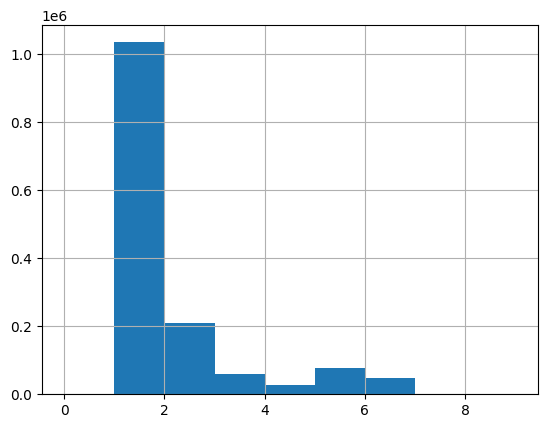

In [36]:
train_df["passenger_count"].hist(bins=9)

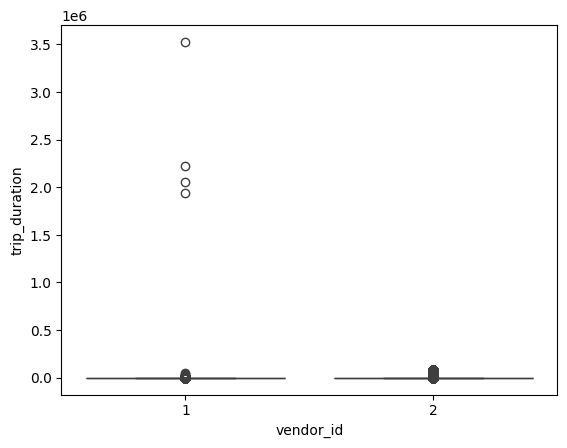

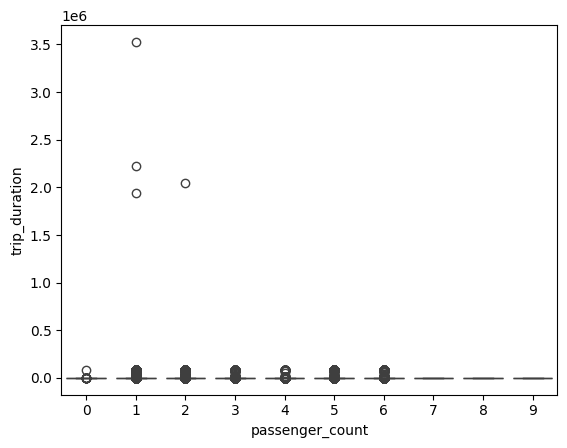

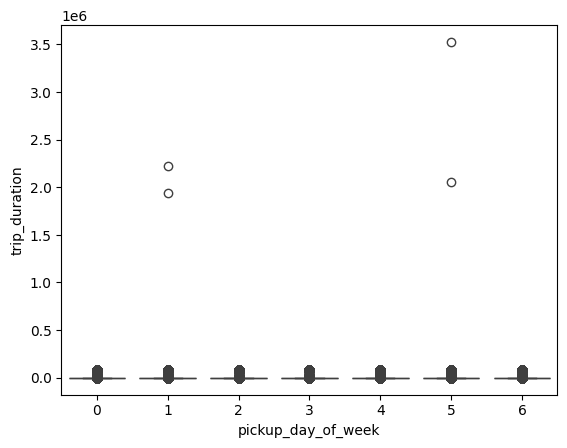

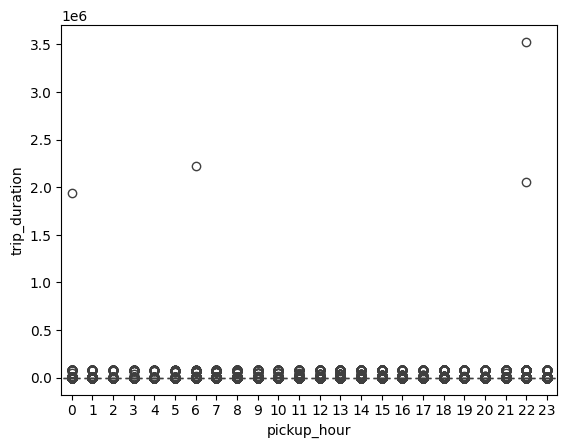

In [37]:
col_group = train_df[["vendor_id", "passenger_count", "pickup_day_of_week", "pickup_hour"]]

for col in col_group:
    sns.boxplot(x=col, y="trip_duration", data=train_df)
    plt.show()

Text(0, 0.5, 'Duration(s)')

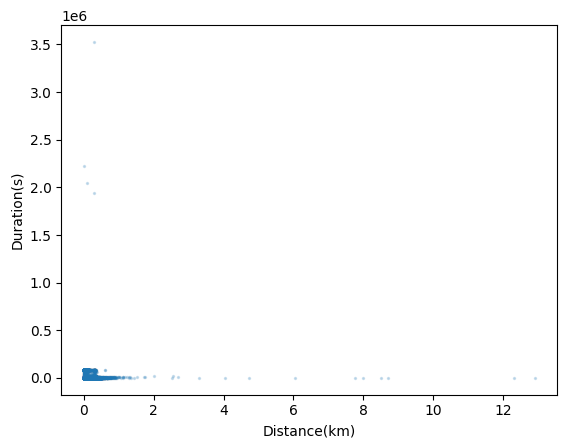

In [38]:
plt.scatter(train_df["trip_distance"], train_df["trip_duration"], alpha=0.2, s=2)
plt.xlabel("Distance(km)")
plt.ylabel("Duration(s)")

<Axes: xlabel='pickup_hour'>

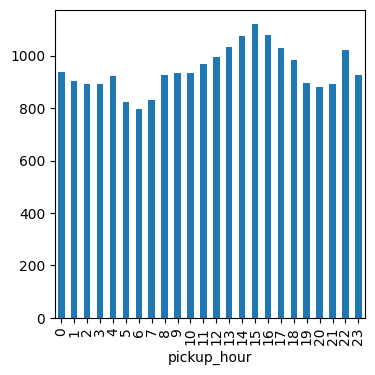

In [39]:
# Trip Duration vs Pickup Hour

train_df.groupby("pickup_hour")["trip_duration"].mean().plot(kind="bar", figsize=(4,4))

<Axes: xlabel='pickup_day_of_week'>

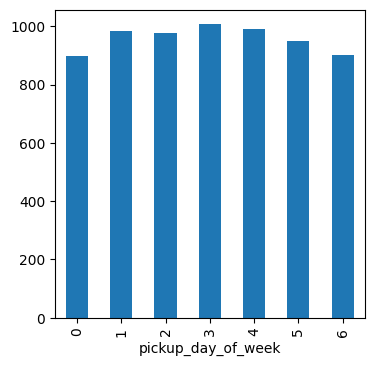

In [40]:
# Trip Duration vs Pickup Day of Week

train_df.groupby("pickup_day_of_week")["trip_duration"].mean().plot(kind="bar", figsize=(4,4))

In [41]:
# Correlations

corr = train_df[["trip_duration", "vendor_id", "passenger_count", "trip_distance"]].corr()
corr["trip_duration"].sort_values(ascending=False)

trip_duration      1.000000
trip_distance      0.094738
vendor_id          0.020304
passenger_count    0.008471
Name: trip_duration, dtype: float64

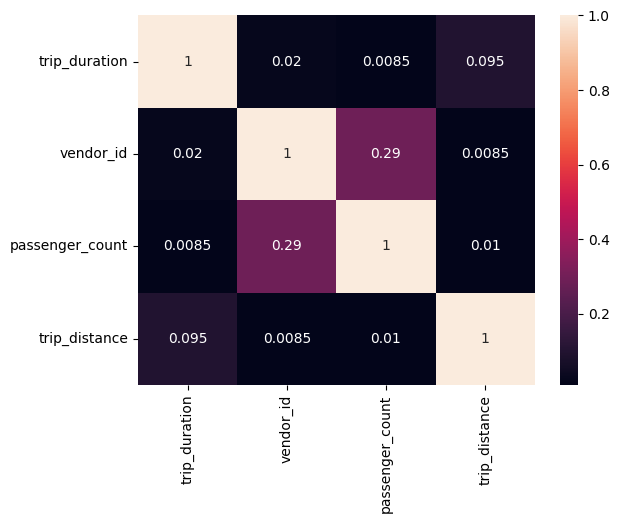

In [42]:
sns.heatmap(corr, annot = True)
plt.show()

### Finishing Touches

In [43]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 14 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1458644 non-null  str           
 1   vendor_id           1458644 non-null  int64         
 2   pickup_datetime     1458644 non-null  datetime64[us]
 3   dropoff_datetime    1458644 non-null  str           
 4   passenger_count     1458644 non-null  int64         
 5   pickup_longitude    1458644 non-null  float64       
 6   pickup_latitude     1458644 non-null  float64       
 7   dropoff_longitude   1458644 non-null  float64       
 8   dropoff_latitude    1458644 non-null  float64       
 9   store_and_fwd_flag  1458644 non-null  str           
 10  trip_duration       1458644 non-null  int64         
 11  trip_distance       1458644 non-null  float64       
 12  pickup_day_of_week  1458644 non-null  int32         
 13  pickup_hour         145

In [44]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 625134 entries, 0 to 625133
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   id                  625134 non-null  str           
 1   vendor_id           625134 non-null  int64         
 2   pickup_datetime     625134 non-null  datetime64[us]
 3   passenger_count     625134 non-null  int64         
 4   pickup_longitude    625134 non-null  float64       
 5   pickup_latitude     625134 non-null  float64       
 6   dropoff_longitude   625134 non-null  float64       
 7   dropoff_latitude    625134 non-null  float64       
 8   store_and_fwd_flag  625134 non-null  str           
 9   trip_distance       625134 non-null  float64       
 10  pickup_day_of_week  625134 non-null  int32         
 11  pickup_hour         625134 non-null  int32         
dtypes: datetime64[us](1), float64(5), int32(2), int64(2), str(2)
memory usage: 52.5 MB


In [45]:
train_df.to_pickle("train.pkl")
test_df.to_pickle("test.pkl")